# Análise Exploratória de Dados - Synthea Master Table

Este notebook realiza uma análise exploratória dos dados unificados do Synthea, focando em demografia, condições clínicas e aspectos financeiros.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
from matplotlib.ticker import FuncFormatter

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
pd.set_option('display.max_columns', None)

In [2]:
def formatar_valores(x, pos):
    if abs(x) >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif abs(x) >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif abs(x) >= 1e3:
        return f'{x*1e-3:.1f}Mil'
    else:
        return f'{x:.0f}'

## 1. Carregamento dos Dados

In [13]:
file_path = 'synthea_sample_data/master_table.csv'
df = pd.read_csv(file_path, low_memory=False)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
df.head()

Linhas: 74047
Colunas: 109


,PATIENT,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,ENCOUNTER,START,STOP,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,ORGANIZATION_provider,NAME,GENDER_provider,SPECIALITY,ADDRESS_provider,CITY_provider,STATE_provider,ZIP_provider,LAT_provider,LON_provider,ENCOUNTERS,PROCEDURES,NAME_org,ADDRESS_org,CITY_org,STATE_org,ZIP_org,LAT_org,LON_org,PHONE,REVENUE,UTILIZATION,NAME_payer,OWNERSHIP,ADDRESS_payer,CITY_payer,STATE_HEADQUARTERED,ZIP_payer,PHONE_payer,AMOUNT_COVERED,AMOUNT_UNCOVERED,REVENUE_payer,COVERED_ENCOUNTERS,UNCOVERED_ENCOUNTERS,COVERED_MEDICATIONS,UNCOVERED_MEDICATIONS,COVERED_PROCEDURES,UNCOVERED_PROCEDURES,COVERED_IMMUNIZATIONS,UNCOVERED_IMMUNIZATIONS,UNIQUE_CUSTOMERS,QOLS_AVG,MEMBER_MONTHS,START_condition,STOP_condition,SYSTEM,CODE_condition,DESCRIPTION_condition,START_medication,STOP_medication,PAYER_medication,CODE_medication,DESCRIPTION_medication,BASE_COST,PAYER_COVERAGE_medication,DISPENSES,TOTALCOST,REASONCODE_medication,REASONDESCRIPTION_medication,START_procedure,STOP_procedure,SYSTEM_procedure,CODE_procedure,DESCRIPTION_procedure,BASE_COST_procedure,REASONCODE_procedure,REASONDESCRIPTION_procedure
0,f1aa52b9-aded-3188-9386-012244805ebf,1989-06-20,NaN,999-96-7640,S99993266,X52137231X,Mr.,Maurice742,Corey514,Brekke496,NaN,NaN,M,white,nonhispanic,M,Malden Massachusetts US,476 Wolff Landing Suite 16,Dedham,Massachusetts,Norfolk County,25021.0,2090,42.294422,-71.141595,182949.51,22601.32,108063,f1aa52b9-aded-3188-89de-02f5e685ce85,2007-08-28T13:10:24Z,2007-08-28T13:52:05Z,50c47685-8125-3c50-8311-8bd7ba9e9108,c43464a9-e8d8-3dde-87ec-abccb3e401fb,d31fccc3-1767-390d-966a-22a5156f4219,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN,50c47685-8125-3c50-8311-8bd7ba9e9108,Beth967 McKenzie376,F,GENERAL PRACTICE,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,33,0,BOSTON MEDICAL CENTER CORPORATION-,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,6173234440,0.0,33,UnitedHealthcare,PRIVATE,NaN,NaN,NaN,NaN,NaN,1376252.2,474744.87,1441598.0,1263,0,348,0,1993,0,319,0,10,0.913465,2916,2007-08-28,NaN,http://snomed.info/sct,105531004.0,Housing unsatisfactory (finding),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f1aa52b9-aded-3188-9386-012244805ebf,1989-06-20,NaN,999-96-7640,S99993266,X52137231X,Mr.,Maurice742,Corey514,Brekke496,NaN,NaN,M,white,nonhispanic,M,Malden Massachusetts US,476 Wolff Landing Suite 16,Dedham,Massachusetts,Norfolk County,25021.0,2090,42.294422,-71.141595,182949.51,22601.32,108063,f1aa52b9-aded-3188-89de-02f5e685ce85,2007-08-28T13:10:24Z,2007-08-28T13:52:05Z,50c47685-8125-3c50-8311-8bd7ba9e9108,c43464a9-e8d8-3dde-87ec-abccb3e401fb,d31fccc3-1767-390d-966a-22a5156f4219,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN,50c47685-8125-3c50-8311-8bd7ba9e9108,Beth967 McKenzie376,F,GENERAL PRACTICE,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,33,0,BOSTON MEDICAL CENTER CORPORATION-,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,6173234440,0.0,33,UnitedHealthcare,PRIVATE,NaN,NaN,NaN,NaN,NaN,1376252.2,474744.87,1441598.0,1263,0,348,0,1993,0,319,0,10,0.913465,2916,2007-08-28,NaN,http://snomed.info/sct,224299000.0,Received higher education (finding),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,f1aa52b9-aded-3188-9386-012244805ebf,1989-06-20,NaN,999-96-7640,S99993266,X52137231X,Mr.,Maurice742,Corey514,Brekke496,NaN,NaN,M,white,nonhispanic,M,Malden Massachusetts US,476 Wolff Landing Suite 16,Dedham,Massachusetts,Norfolk County,25021.0,2090,42.294422,-71.141595,182949.51,22601.32,108063,f1aa52b9-aded-3188-0421-249ad1d4b3c3,2008-09-23T13:10:24Z,2008-09-23T14

## Conversão da coluna de BIRTHDATE e cálculo da idade

In [ ]:
df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE']).dt.date
df['AGE'] = df['BIRTHDATE'].apply(lambda x : round((datetime.date.today() - x).days/365))

In [28]:
df.head()

,PATIENT,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,ENCOUNTER,START,STOP,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,ORGANIZATION_provider,NAME,GENDER_provider,SPECIALITY,ADDRESS_provider,CITY_provider,STATE_provider,ZIP_provider,LAT_provider,LON_provider,ENCOUNTERS,PROCEDURES,NAME_org,ADDRESS_org,CITY_org,STATE_org,ZIP_org,LAT_org,LON_org,PHONE,REVENUE,UTILIZATION,NAME_payer,OWNERSHIP,ADDRESS_payer,CITY_payer,STATE_HEADQUARTERED,ZIP_payer,PHONE_payer,AMOUNT_COVERED,AMOUNT_UNCOVERED,REVENUE_payer,COVERED_ENCOUNTERS,UNCOVERED_ENCOUNTERS,COVERED_MEDICATIONS,UNCOVERED_MEDICATIONS,COVERED_PROCEDURES,UNCOVERED_PROCEDURES,COVERED_IMMUNIZATIONS,UNCOVERED_IMMUNIZATIONS,UNIQUE_CUSTOMERS,QOLS_AVG,MEMBER_MONTHS,START_condition,STOP_condition,SYSTEM,CODE_condition,DESCRIPTION_condition,START_medication,STOP_medication,PAYER_medication,CODE_medication,DESCRIPTION_medication,BASE_COST,PAYER_COVERAGE_medication,DISPENSES,TOTALCOST,REASONCODE_medication,REASONDESCRIPTION_medication,START_procedure,STOP_procedure,SYSTEM_procedure,CODE_procedure,DESCRIPTION_procedure,BASE_COST_procedure,REASONCODE_procedure,REASONDESCRIPTION_procedure,AGE
0,f1aa52b9-aded-3188-9386-012244805ebf,1989-06-20,NaN,999-96-7640,S99993266,X52137231X,Mr.,Maurice742,Corey514,Brekke496,NaN,NaN,M,white,nonhispanic,M,Malden Massachusetts US,476 Wolff Landing Suite 16,Dedham,Massachusetts,Norfolk County,25021.0,2090,42.294422,-71.141595,182949.51,22601.32,108063,f1aa52b9-aded-3188-89de-02f5e685ce85,2007-08-28T13:10:24Z,2007-08-28T13:52:05Z,50c47685-8125-3c50-8311-8bd7ba9e9108,c43464a9-e8d8-3dde-87ec-abccb3e401fb,d31fccc3-1767-390d-966a-22a5156f4219,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN,50c47685-8125-3c50-8311-8bd7ba9e9108,Beth967 McKenzie376,F,GENERAL PRACTICE,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,33,0,BOSTON MEDICAL CENTER CORPORATION-,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,6173234440,0.0,33,UnitedHealthcare,PRIVATE,NaN,NaN,NaN,NaN,NaN,1376252.2,474744.87,1441598.0,1263,0,348,0,1993,0,319,0,10,0.913465,2916,2007-08-28,NaN,http://snomed.info/sct,105531004.0,Housing unsatisfactory (finding),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37
1,f1aa52b9-aded-3188-9386-012244805ebf,1989-06-20,NaN,999-96-7640,S99993266,X52137231X,Mr.,Maurice742,Corey514,Brekke496,NaN,NaN,M,white,nonhispanic,M,Malden Massachusetts US,476 Wolff Landing Suite 16,Dedham,Massachusetts,Norfolk County,25021.0,2090,42.294422,-71.141595,182949.51,22601.32,108063,f1aa52b9-aded-3188-89de-02f5e685ce85,2007-08-28T13:10:24Z,2007-08-28T13:52:05Z,50c47685-8125-3c50-8311-8bd7ba9e9108,c43464a9-e8d8-3dde-87ec-abccb3e401fb,d31fccc3-1767-390d-966a-22a5156f4219,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN,50c47685-8125-3c50-8311-8bd7ba9e9108,Beth967 McKenzie376,F,GENERAL PRACTICE,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,33,0,BOSTON MEDICAL CENTER CORPORATION-,4199 WASHINGTON ST,ROSLINDALE,MA,21311733,42.287145,-71.127753,6173234440,0.0,33,UnitedHealthcare,PRIVATE,NaN,NaN,NaN,NaN,NaN,1376252.2,474744.87,1441598.0,1263,0,348,0,1993,0,319,0,10,0.913465,2916,2007-08-28,NaN,http://snomed.info/sct,224299000.0,Received higher education (finding),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37
2,f1aa52b9-aded-3188-9386-012244805ebf,1989-06-20,NaN,999-96-7640,S99993266,X52137231X,Mr.,Maurice742,Corey514,Brekke496,NaN,NaN,M,white,nonhispanic,M,Malden Massachusetts US,476 Wolff Landing Suite 16,Dedham,Massachusetts,Norfolk County,25021.0,2090,42.294422,-71.141595,182949.51,22601.32,108063,f1aa52b9-aded-3188-0421-249ad1d4b3c3,2008-09-23T13:10:24Z,200

## 2. Visão Geral e Limpeza Básica

In [4]:
# Informações sobre tipos de dados e valores nulos
df.info(max_cols=20)  # Limitado para visualização

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74047 entries, 0 to 74046
Columns: 109 entries, PATIENT to REASONDESCRIPTION_procedure
dtypes: float64(33), int64(18), object(58)
memory usage: 61.6+ MB


## 3. Análise Demográfica

/var/folders/m6/5gldbqjd7y97574965jjjdsw0000gn/T/ipykernel_22020/1622589125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='GENDER', ax=axes[0], palette='viridis')
/var/folders/m6/5gldbqjd7y97574965jjjdsw0000gn/T/ipykernel_22020/1622589125.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='RACE', ax=axes[1], palette='magma')


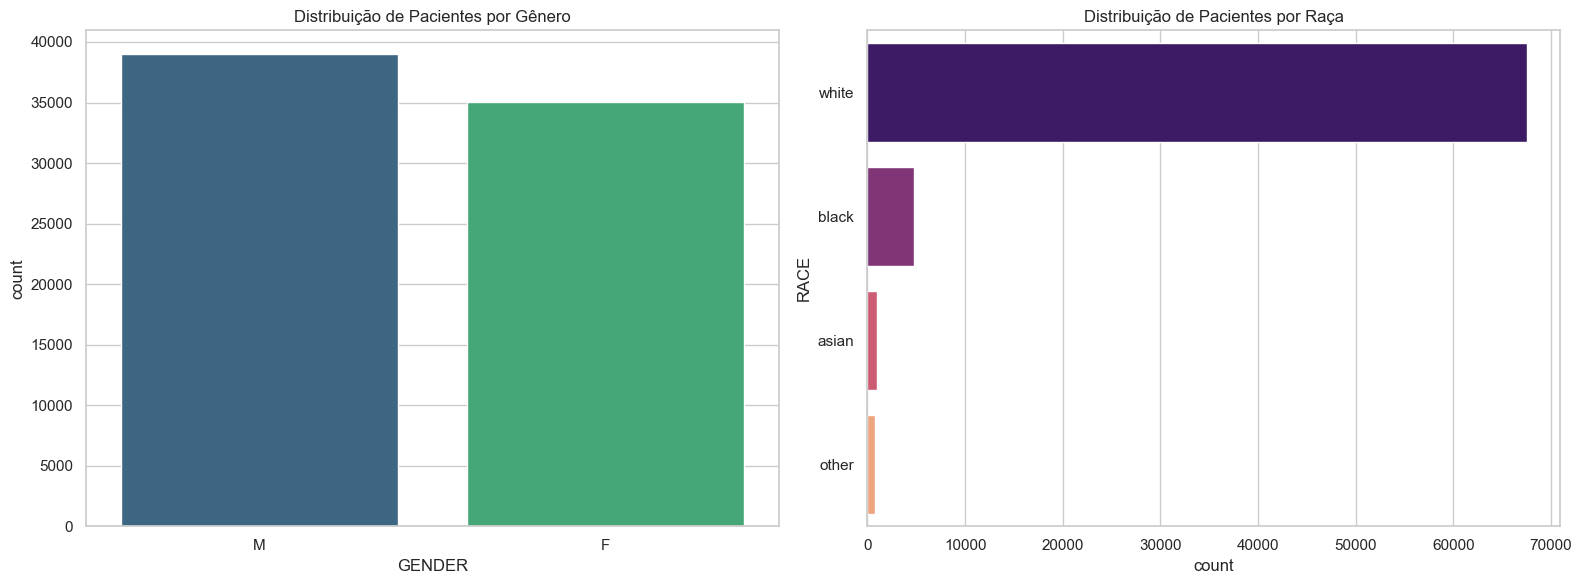

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribuição por Gênero
sns.countplot(data=df, x='GENDER', ax=axes[0], palette='viridis')
axes[0].set_title('Distribuição de Pacientes por Gênero')

# Distribuição por Raça
sns.countplot(data=df, y='RACE', ax=axes[1], palette='magma')
axes[1].set_title('Distribuição de Pacientes por Raça')

plt.tight_layout()
plt.show()

## 4. Análise Clínica: Principais Condições
Vamos analisar quais são os diagnósticos mais comuns na base de dados.

/var/folders/m6/5gldbqjd7y97574965jjjdsw0000gn/T/ipykernel_22020/3312633955.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_conditions.values, y=top_conditions.index, palette='rocket')


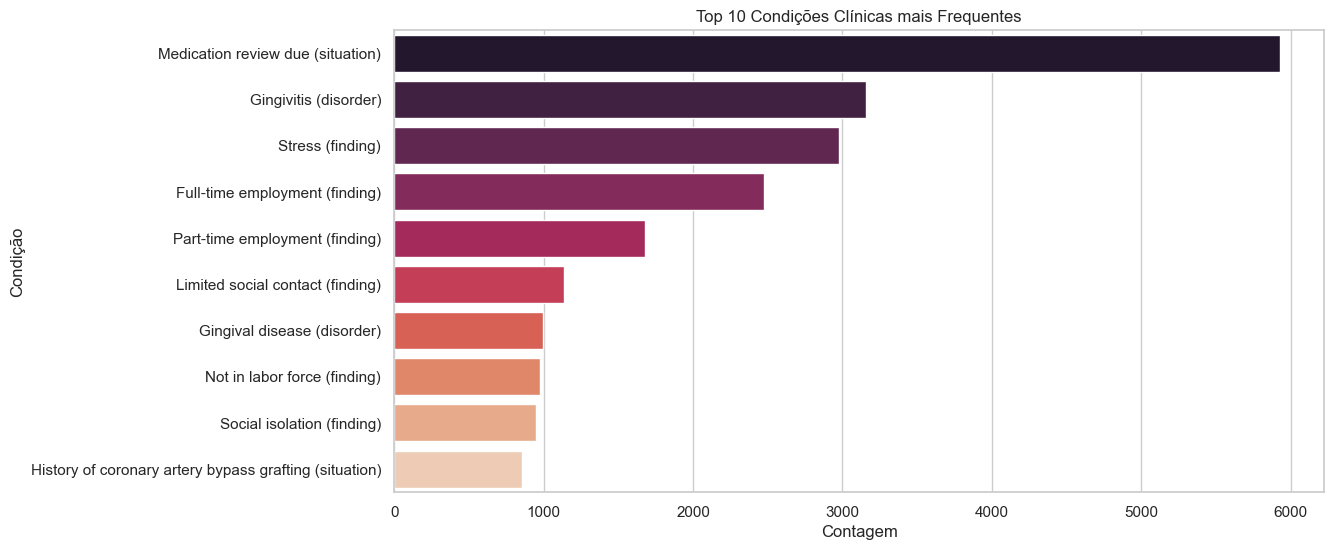

In [6]:
# Como um paciente pode ter múltiplas condições (devido ao join), pegamos a coluna de descrição da condição
if 'DESCRIPTION_condition' in df.columns:
    top_conditions = df['DESCRIPTION_condition'].value_counts().head(10)
    
    sns.barplot(x=top_conditions.values, y=top_conditions.index, palette='rocket')
    plt.title('Top 10 Condições Clínicas mais Frequentes')
    plt.xlabel('Contagem')
    plt.ylabel('Condição')
    plt.show()
else:
    print("Coluna 'DESCRIPTION_condition' não encontrada. Verifique se o join foi realizado corretamente.")

## 5. Análise Financeira: Despesas de Saúde
Análise dos gastos acumulados dos pacientes.

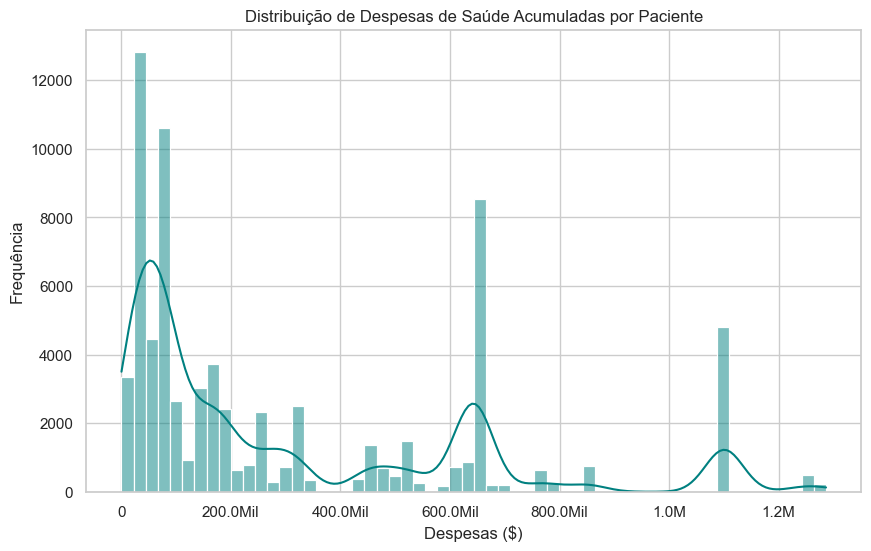

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['HEALTHCARE_EXPENSES'], kde=True, color='teal')
plt.title('Distribuição de Despesas de Saúde Acumuladas por Paciente')
plt.xlabel('Despesas ($)')
plt.ylabel('Frequência')
plt.gca().xaxis.set_major_formatter(FuncFormatter(formatar_valores))

## 6. Relação entre Idade (estimada) e Gastos
Nota: Como é uma amostra, a idade será calculada de forma simplificada.

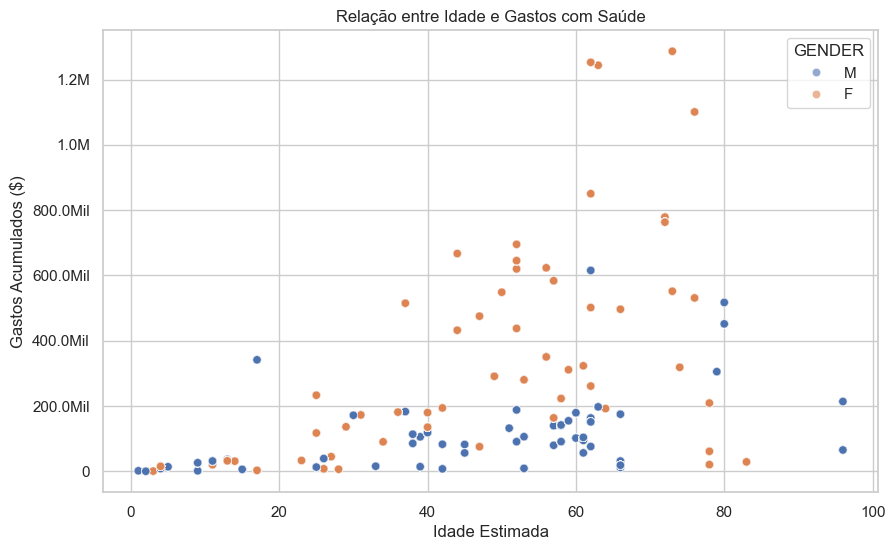

In [11]:
df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE'])
df['AGE'] = 2026 - df['BIRTHDATE'].dt.year  # Usando 2026 como ano base do dataset

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AGE', y='HEALTHCARE_EXPENSES', hue='GENDER', alpha=0.6)
plt.title('Relação entre Idade e Gastos com Saúde')
plt.xlabel('Idade Estimada')
plt.ylabel('Gastos Acumulados ($)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_valores))

## 7. Análise de Pagadores (Payers)
Quais seguradoras estão cobrindo a maior parte dos custos?

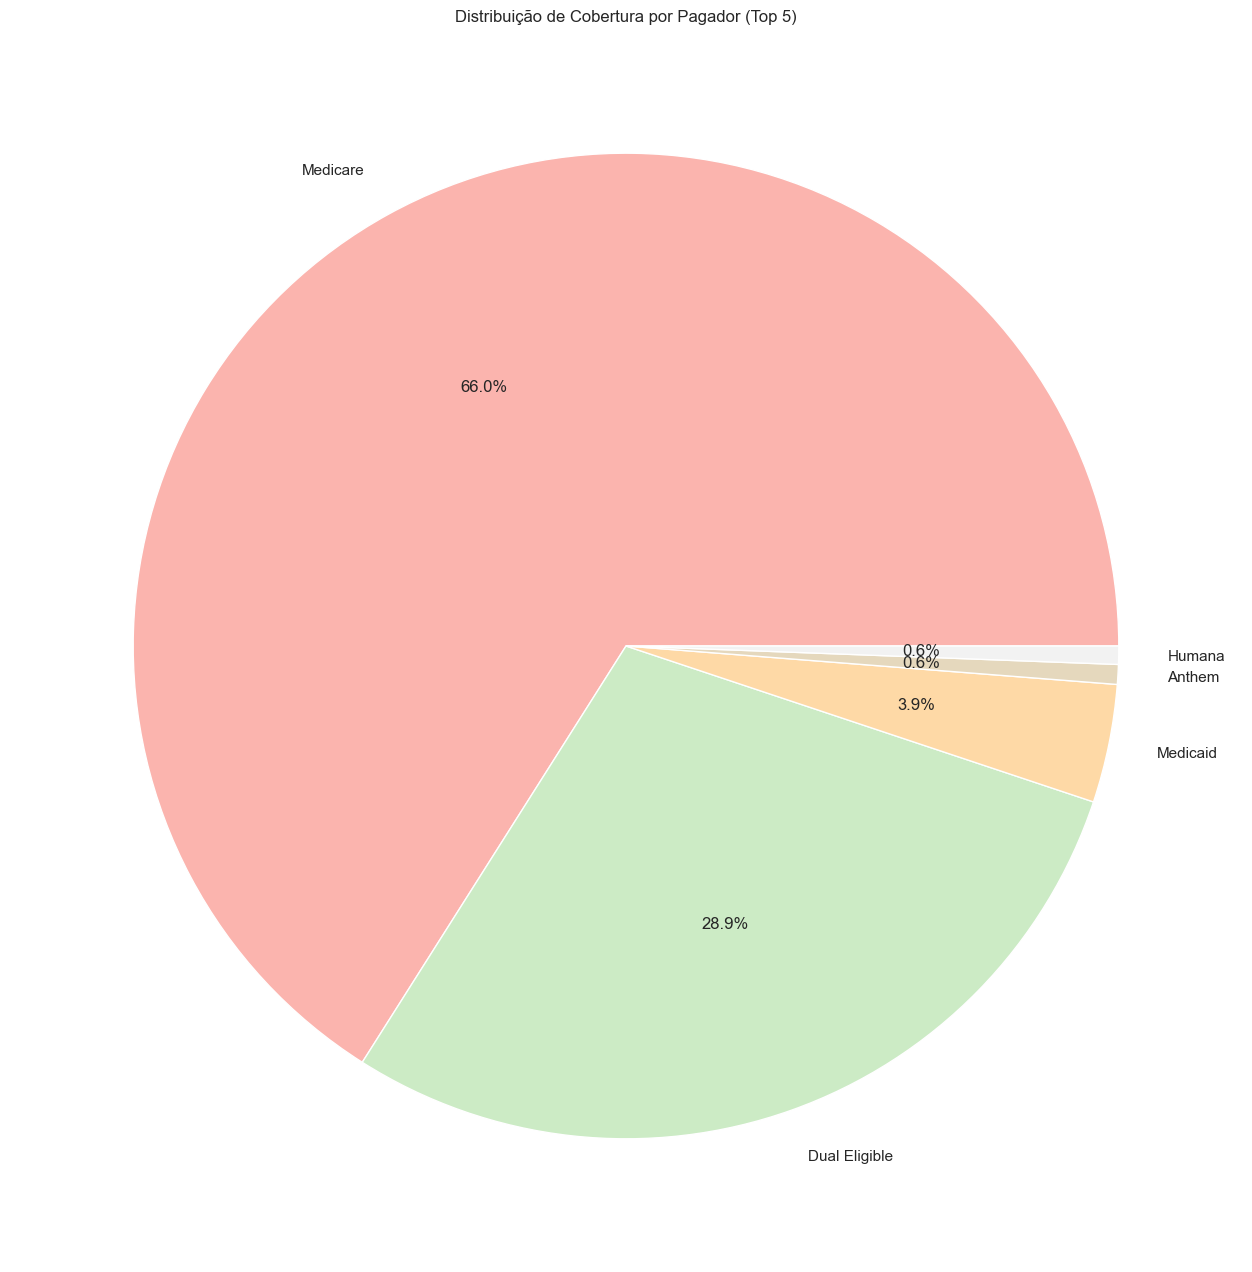

In [10]:
if 'NAME_payer' in df.columns:
    payer_coverage = df.groupby('NAME_payer')['PAYER_COVERAGE'].sum().sort_values(ascending=False).head(5)
    
    plt.figure(figsize=(20, 16))
    payer_coverage.plot(kind='pie', autopct='%1.1f%%', colormap='Pastel1')
    plt.title('Distribuição de Cobertura por Pagador (Top 5)')
    plt.ylabel('')
    plt.show()
else:
    print("Coluna 'NAME_payer' não encontrada.")